# テーマ2 データ可視化とEDA

今回は実際のデータを使い、目的に合ったグラフの選び方と読み方を学びます。まず、数値の並びと点数表を使ってNumPyの配列を学びます。次に、Irisデータセットで花の長さ・幅の分布や種類ごとの違いを調べます。最後に、広島・津山・金沢の2025年の月平均気温を折れ線グラフにし、時間に沿った変化を見ます。

## 到達目標

- NumPyを読み込み、配列（行列）の計算ができる
- データセットの1行・1列が表すものを確認し、DataFrameの基本統計量を読める
- 分布、種類ごとの差、特徴量どうしの関係をグラフで調べられる
- 気象データを使い、折れ線グラフで月ごとの変化を読める
- 図から読み取ったことを「事実・解釈・限界」に分けて説明できる

## 今日の成果物

- NumPy・データ確認・可視化の結果をまとめた **レポート1本**

## 進め方

上から順にセルを実行して、表とグラフの読み方を学びます。途中の `TODO` は授業中に試すための練習です。
Step 0〜7でIrisを分析し、Step 8で気象データの変化を確認します。その後、最後の「まとめとレポート」の演習A〜Cの結果を1本にまとめて提出してください。
巻末の発展例とワインデータは、余裕がある場合に試す参考例です。


**やり直すとき:** カーネルを再起動して上から順に実行します。変数を変更したら、その変数を使う後続セルも再実行してください。提出前には「すべてのセルを実行」で、古い図や出力が残っていないか確認します。


## EDAとは何か

EDA は **Exploratory Data Analysis** の略で、日本語では探索的データ分析と呼ばれます。
目的は、モデルを作る前にデータを観察して仮説を立てることです。

この回では、数値計算よりも**グラフを読むこと**を重視します。

| 観点 | 見るもの | 使うグラフ |
| --- | --- | --- |
| 分布 | 値がどの範囲に多いか | ヒストグラム |
| 関係 | 2つの数値変数の関係 | 散布図 |
| 大小比較 | カテゴリごとの平均や件数 | 棒グラフ |
| 構成比 | 全体に占めるカテゴリの割合 | 円グラフ |
| 変化 | 時間など、順序のある軸に沿った値の変化 | 折れ線グラフ |
| グループ差（詳細） | クラスごとの中央値・ばらつき | 箱ひげ図 |

EDA ではグラフを作って終わりにせず、図から読み取れることを「事実・解釈・限界」に分けて書きます。

平均値のカテゴリ間比較には棒グラフを使い、時間など順序に沿った変化には折れ線グラフを使います。Step 4では特徴量ごとに種類別の平均を棒の高さで比べ、Step 8では月平均気温を折れ線で結んで時間に沿った変化を見ます。


### グラフを読むときの型

グラフを見たら、次の3つを分けて書くと考えやすくなります。

1. **事実**: 図にそのまま見えていること
2. **解釈**: その事実から考えられること
3. **限界**: その図だけではまだ言えないこと

**例:** Irisデータにおいて`petal length (cm)` は種類ごとに分布が分かれて見える。
これは分類に役立つ特徴量かもしれない。ただし、図だけでは新しいデータを
必ず正しく分類できるとは言えない。

### 分析の流れ

| Step | やること | 確認する観点 |
| --- | --- | --- |
| 準備 | NumPyの配列・行列を扱う | 配列の形、行・列ごとの平均、配列全体の計算 |
| 0 | ライブラリとIrisデータを準備 | データセットとDataFrameの意味 |
| 1 | データを確認 | 行数、列名、基本統計量、種類ごとの件数 |
| 2 | 全体のヒストグラム | 値の広がり、山の形 |
| 3 | 種類別ヒストグラム | グループごとの分布 |
| 4 | 棒グラフで平均を比較 | 特徴量ごとの種類間の差 |
| 5 | 円グラフ | 各種類の構成比 |
| 6 | 箱ひげ図 | 中央値、ばらつき、外れ値候補 |
| 7 | 散布図 | 2つの特徴量の関係 |
| 8 | 気象データの折れ線グラフ | 月ごとの気温の変化、3地点の違い |

Step 0〜7はIris、Step 8は気象データを使います。「まとめとレポート」で、授業中の結果を演習A〜Cにまとめます。発展の図とワインデータは巻末の参考例です。



## 実行の準備

Pythonでは様々な事ができますが、Python単体でできることは限られています。たとえば、Python単体では、高度な統計処理やグラフの作成は簡単にはできません。一方で、Pythonでは、高度な処理を簡単に実行できるようにしたパッケージ（ライブラリ）が豊富に提供されており、目的に応じパッケージをインストールすることで、様々な機能を追加することができます。

データ解析でよく用いられるのは、ベクトル・行列計算、表データ、統計・機械学習、グラフ作成です。これらの機能はPython単体では提供されないので、`numpy`・`pandas`・`scikit-learn`・`matplotlib`・`seaborn` などのパッケージが必要となります。

今回のコードを実行した時、
```
ModuleNotFoundError
```
が出る場合は、Notebookを再起動し、はじめのコードセルで
```
%pip install numpy pandas scikit-learn matplotlib seaborn
```
を実行してください。

## 準備: NumPy で配列・行列を扱う

数値計算やデータ分析では、数値が並んだ配列（ベクトル・行列など）をまとめて扱うことが多くあります。

**NumPy** は、数値計算のための基本ライブラリです。Pythonのリストと比べて、次のような特徴があります。

- **高速な数値計算**: 多くの数値をまとめて処理する機能が用意されています
- **簡潔な書き方**: 配列全体に対する計算を、1行のコードで書けます
- **ベクトル・行列計算**: 1次元配列をベクトル、2次元配列を行列として扱い、さまざまな計算ができます

### 1次元配列：値を一列に並べる

**配列**は、複数の値を順番に並べてまとめたものです。1次元配列は、値が一列に並んだリストのような形です。

`np.array()` にPythonのリストを渡すと、NumPy配列を作れます。

```python
v = np.array([10, 20, 30])
```

`[10, 20, 30]` が元のリスト、`np.array(...)` が配列を作る処理、`v` が作った配列を入れる変数です。

次のセルではNumPyを `np` という名前で読み込み、配列の値・形・平均を表示します。
`v.shape` の `(3,)` は「3個の要素を持つ1次元配列」という意味です。`v.mean()` は `(10 + 20 + 30) / 3` を計算します。


In [1]:
# ===== 準備: 1次元配列（ベクトル） =====
import numpy as np  # NumPyを読み込み、npという短い名前で使う

v = np.array([10, 20, 30])

print('v =', v)
print('形 =', v.shape)  # (3,)：要素が3個の1次元配列
print('平均 =', v.mean())  # 3つの値の平均


v = [10 20 30]
形 = (3,)
平均 = 20.0


### 2次元配列：値を行と列に並べる

2次元配列は、値を行と列に並べた表のような形です。1次元配列を同じ長さで並べた「ベクトルの集まり」、つまり行列として見ることができます。
さらに高次元の配列は、例えば複数の行列を積み重ねたものとして捉えられます。この回では1次元と2次元を扱います。

たとえば、次の表の数値部分を2次元配列として表せます。横に並ぶのが**行**、縦に並ぶのが**列**です。

| | 列1 | 列2 | 列3 |
| --- | ---: | ---: | ---: |
| 行1 | 80 | 65 | 70 |
| 行2 | 90 | 88 | 92 |
| 行3 | 75 | 60 | 78 |

1行分の値を1つのリストにし、そのリストを3つ並べて `np.array()` に渡します。

```python
scores = np.array([
    [80, 65, 70],
    [90, 88, 92],
    [75, 60, 78]
])
```

この配列の `shape` は `(3, 3)` で、「3行、3列」を意味します。表の行名や列名は説明のために付けたもので、配列には数値だけが入っています。

### axisで平均を求める方向を指定する

同じ表でも、行ごとに平均を求めるか、列ごとに平均を求めるかで、まとめる値が異なります。`mean()` の `axis` で、どちらをまとめるか指定します。

| 書き方 | まとめる値 | 結果 |
| --- | --- | --- |
| `scores.mean(axis=1)` | 同じ行の値を横にまとめる | 各行の平均（3個） |
| `scores.mean(axis=0)` | 同じ列の値を縦にまとめる | 各列の平均（3個） |

例えば、行1の平均は `(80 + 65 + 70) / 3`、列1の平均は `(80 + 90 + 75) / 3` です。次のセルの出力は、表の行・列の順番に対応します。

この段階では、次の操作を確認できれば十分です。

- 配列の形（`shape`）を確認する
- 行ごと、列ごとに平均を計算する
- 配列全体への四則演算を行う

平均以外にも、内積・転置など、さまざまなベクトル・行列演算の機能を使うことができます。

**用語の確認:**

- **配列（array）**: 値を順番に並べてまとめたもの。1次元は値の並び、2次元は行と列のある形です
- **shape**: 配列の形。1次元では `(要素数,)`、2次元では `(行数, 列数)` で表します
- **axis**: 集計するときに値をまとめる軸。`axis=0` では各列の結果、`axis=1` では各行の結果が残ります

**確認問題:** 2行3列の配列なら、`shape` は `(2, 3)`、`mean(axis=0)` の結果は3個、`mean(axis=1)` の結果は2個になります。`axis` はまとめて消える軸と考え、結果に行・列のどちらが残るか確認しましょう。


In [2]:
# ===== 準備: NumPy 配列（2次元） =====
# 2次元配列（行列）を作成する例です。3行3列の配列を作ります。
# 見た目はリストのリストと似ていますが、NumPy 配列は数値計算に特化したデータ構造です。
scores = np.array([
    [80, 65, 70],
    [90, 88, 92],
    [75, 60, 78]
])

print('scores =')
print(scores)
print('形 =', scores.shape)  # 配列のサイズを表示します。 (行数, 列数) = (3, 3)
print('各行の平均 =', scores.mean(axis=1))  # 各行の3つの値をまとめる
print('各列の平均 =', scores.mean(axis=0))  # 各列の3つの値をまとめる

# NumPy の強み: 配列全体を一度に計算できる
print('全要素に 10 点加算 =')
print(scores + 10)
print('全要素を 2 倍 =')
print(scores * 2)

# TODO: 1つ値を変えて、平均がどう変わるか確認する
# TODO: scores + 10 の結果が、元の scores を書き換えないことを確認する
#       （再度 print(scores) を実行して、元の値のままであることを確かめてください）

scores =
[[80 65 70]
 [90 88 92]
 [75 60 78]]
形 = (3, 3)
各行の平均 = [71.66666667 90.         71.        ]
各列の平均 = [81.66666667 71.         80.        ]
全要素に 10 点加算 =
[[ 90  75  80]
 [100  98 102]
 [ 85  70  88]]
全要素を 2 倍 =
[[160 130 140]
 [180 176 184]
 [150 120 156]]


### 配列全体への計算：ベクトル化

前のセルの `scores + 10` は全ての要素に10を足し、`scores * 2` は全ての要素を2倍します。こうした計算は、元の `scores` を書き換えず、新しい配列を作ります。

`for` ループは、値を1つずつ取り出して処理するときに便利です。一方、NumPy配列の各要素に同じ計算をしたい場合は、配列全体への計算を使うと簡潔に書けます。この書き方を**ベクトル化**と呼びます。

例えば、1次元配列 `v` の各要素を2倍にするときは `v * 2` と書き、`[20, 40, 60]` という配列を得られます。2次元配列でも同じように、全要素に計算を適用できます。

大きな配列では処理が速くなることもありますが、実行時間はデータの大きさや処理内容によって変わります。目的に応じて `for` と配列全体の計算を使い分けます。


## Step 0: データを準備する

ここからは、この回の可視化で使う表形式データを準備します。配列では数値を扱いましたが、分析では列の名前やデータの意味も確認する必要があります。

Pythonで高度な数式処理、表の処理、グラフの描画を行うときは、ライブラリを使うと便利です。あらゆる機能を自分で実装するのは現実的ではありません。そこで、Pythonにない便利な機能をまとめた「道具箱」のようなもの、**ライブラリ**を使い、様々な機能を簡単に使えるようにします。ライブラリを読み込むことで、複雑な処理を短いコードで実行できるようになります。

データ分析では、主に次の 4 つのライブラリを使います。

- **NumPy**: 数値計算・配列処理の基本ライブラリ
- **pandas**: 表形式データを扱うライブラリ。Excel のような行・列構造でデータを操作できます
- **scikit-learn (sklearn)**: 機械学習のライブラリ。データ読み込み、前処理、モデルの学習・評価までを一通り提供します
- **matplotlib**: グラフを描画するライブラリ

**ライブラリの読み込み方:**

`import` を使ってライブラリを読み込みます。よく使うライブラリには短い別名（エイリアス）をつける慣習があります。

- `import numpy as np`: NumPy を `np` という名前で使う
- `import pandas as pd`: pandas を `pd` という名前で使う
- `from sklearn.datasets import load_iris`: scikit-learn の中から `load_iris` という関数だけを取り出す

このステップでは、scikit-learn に同梱されている Iris データセットを読み込み、pandas の DataFrame として準備します。

### データセット

データ解析に用いるデータのセットのことをデータセットと呼びます。

Iris データセットは、アヤメの花の特徴を 150 件収録した表形式データです。機械学習の練習で最もよく使われるデータセットの一つです。

- 1行: 1つの花の観測データ
- 1列: 花びらの長さ、がく片の幅などの特徴量
- `species`: 花の種類（3 種のいずれか）


### 表形式データと DataFrame

**DataFrame とは**

データセットの数値は配列として扱い、NumPyで処理することが可能です。一方で、列名を付けた表として扱うこともできます。pandasというライブラリの `DataFrame` は、行と列で構成される表形式のデータ構造です。Excel のシートに似ており、次のような操作が容易に行えます。

- 列の追加・削除
- 条件に合う行の抽出
- 集計（平均、合計、件数など）

データ分析では、モデルを作る前にまず次を確認します。

- 行数と列数
- 列名
- 先頭数行
- 値の範囲や平均

これは「データが何を表しているかを理解する」ためであり、分析の最初のステップとして重要です。

### 4つの特徴量と単位

| コードで使う列名 | 意味 | 単位 |
| --- | --- | --- |
| `sepal length (cm)` | がく片の長さ | cm |
| `sepal width (cm)` | がく片の幅 | cm |
| `petal length (cm)` | 花びらの長さ | cm |
| `petal width (cm)` | 花びらの幅 | cm |

このNotebookの `df` は、4つの特徴量に `target` と `species` を加えた **150行6列** の表です。`target` と `species` は同じ種類を番号と名前で表した列で、測定項目が6つあるという意味ではありません。


#### 補足: Iris データセットの3種

Iris データセットに収録されている花は、すべてアヤメ属（Iris属）の花です。次の3種がそれぞれ50件ずつ、合計150件収録されています。

| `target` | 種名 | 特徴 |
|----------|--------|------|
| 0 | setosa | 花びらが短く幅も狭い。他の2種と明確に分離しやすい |
| 1 | versicolor | setosa と virginica の中間的な大きさ |
| 2 | virginica | 花びらが長く幅も広い傾向がある |

**ポイント:**

- `target` 列には 0, 1, 2 という数値が入っています。これは上の表の順番に対応しています
- 次のコードセルで `species` 列を作るとき、この数値を種名（`'setosa'` など）に変換しています
- 機械学習では、4つの特徴量（がく片・花びらの長さと幅）から「この花がどの種か」を当てる（分類する）練習によく使われます
- この回の可視化で、種ごとに特徴量の分布がどう違うかをグラフで確認します

`target` の0・1・2はカテゴリの識別番号です。番号の大小や平均に、花の大きさや種類の優劣の意味はありません。表の特徴は、このデータ内での傾向として確認します。


In [3]:
# ===== Step 0: ライブラリ読み込みとデータ準備 =====
from IPython.display import display  # 表をNotebook上に表示する
import pandas as pd # pandas を読み込み、pd という短い名前で使えるようにする
from sklearn.datasets import load_iris # Iris データセットを読み込むための関数を scikit-learn から読み込む

# scikit-learn に同梱されている Iris データセットを読み込む
iris = load_iris(as_frame=True)

# DataFrame としてコピーする
# copy() でコピーすることで、元の iris データを書き換える心配がなくなります
df = iris.frame.copy()

# target (数値) を species (種名) に変換する
# target は 0, 1, 2 の数値で種を表しています。これを 'setosa' などの名前に変換します
# map() は、値を別の値に置き換えるメソッドです
#   dict(enumerate(iris.target_names)) は {0: 'setosa', 1: 'versicolor', 2: 'virginica'} を作ります
#   つまり、0 → 'setosa'、1 → 'versicolor'、2 → 'virginica' に置き換わります
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

# グラフと集計で使う、4つの測定値の列名を保存する
numeric_columns = iris.feature_names

print('行数, 列数 =', df.shape)
display(df.head())  # 先頭5行を表形式で表示する

# ヒント: DataFrame は表のようにデータを扱うための型です
#       load_iris() は scikit-learn に同梱された練習用データです
#       print() と display() の違い:
#         print()  → 文字列として出力（表の構造が崩れやすい）
#         display() → Notebook 上で表形式できれいに表示（列が揃う）
#         表形式のデータを表示するときは display() を使うと見やすいです

行数, 列数 = (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Step 1: データを確認する

列名、基本統計量、件数を確認します。このあと、分布や関係をグラフで確認します。

**使うメソッドの確認:**

- `df.columns`: 列名の一覧（「何のデータが入っているか」を確認する最初のステップ）
- `df[numeric_columns].describe()`: 各列の基本統計量（平均、標準偏差、最小値、最大値など）を一覧表示
- `df['species'].value_counts()`: 指定した列の値ごとに件数を集計（この場合、種ごとに何件あるか）

`numeric_columns` は4つの測定値の列名です。`target` は種類の番号なので、測定値の平均や範囲を調べるときは除いて集計します。

**基本統計量の読み方:** `count` は欠損していない値の件数、`mean` は平均、`std` は標準偏差（値のばらつき）、`min`・`max` は最小値・最大値です。`25%`・`50%`・`75%` は四分位数で、`50%` は中央値です。

`isna().sum()` で列ごとの欠損件数も確認します。欠損があると平均などの集計からその値が除かれるため、各列の `count` を行数と照らし合わせます。


In [4]:
# ===== Step 1: データ確認 =====
# TODO: 先頭5行、列名、基本統計量を確認する
print('列名一覧')
print(df.columns.tolist())  # 列名をリストとして表示
print('\n基本統計量')
display(df[numeric_columns].describe())  # 平均・標準偏差・最小値・最大値など

print('\n種ごとの件数')
display(df['species'].value_counts())  # 種ごとに件数を集計

# ヒント: `df['列名']` で1つの列を取り出せます
#       df[numeric_columns].describe() で各列の平均、標準偏差、最小値、最大値などが確認できます
#       value_counts() は、同じ値がいくつあるかを数える便利なメソッドです
#       \n は print の中で「改行」を表す特別な文字です

# 欠損値（値が記録されていない箇所）の件数を確認する
print('\n列ごとの欠損件数')
display(df.isna().sum())


列名一覧
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']

基本統計量


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



種ごとの件数


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


列ごとの欠損件数


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

### グラフ描画の準備

表の中身を確認できたら、matplotlibとseabornを読み込みます。前者はグラフ描画の基本ライブラリ、後者は表のデータからグラフを描きやすくするライブラリです。
`plt.show()` で作成した図を表示します。

日本語が四角になった場合は、利用環境に日本語フォントが必要です。下の候補名をインストール済みのフォント名に変えるか、タイトル・軸ラベルを英語にして描き直してください。


In [5]:
# ===== ライブラリ読み込み =====
import matplotlib.pyplot as plt # グラフ描画用: 棒グラフや折れ線グラフなど、さまざまな図を描くための基本ライブラリ
import seaborn as sns           # データ可視化用: matplotlib をより美しく、より簡単に使えるようにした高機能ライブラリ

# グラフの見た目をきれいにする設定
# 'whitegrid' は背景にうっすらと罫線を引くスタイル。データの高低が見やすくなります。
sns.set_theme(style='whitegrid')

# 日本語をグラフに表示するためのフォント設定（日本語がないと文字化けして ■ になってしまいます）
plt.rcParams['font.family'] = 'sans-serif' #フォントの設定
plt.rcParams['font.sans-serif'] = [
    'Hiragino Sans', 'Yu Gothic', 'Noto Sans CJK JP', 'IPAexGothic',
    'Arial Unicode MS', 'DejaVu Sans'
] #フォントの設定: macOS / Windows / Linux でそれぞれ日本語を表示できるフォントを順に試します

# 同じ種類は、どの図でも同じ順序・同じ色で表示する
species_order = list(iris.target_names)
species_palette = dict(zip(species_order, sns.color_palette('colorblind', 3)))


---

### Step 2: 平均だけでは分からない「分布」を見る

平均はデータの代表値ですが、値が狭い範囲に集まっているか、複数の山があるかまでは分かりません。まずは花びらの長さを取り出して、度数分布表とヒストグラムで値の広がりを調べます。

ヒストグラムは、値の範囲を区間（**階級**）に分け、その区間に入る件数（**度数**）を棒の高さで表す図です。`n_bins` は階級数です。階級数を増やすと区間が細かくなります。

以下ではNumPyの `histogram()` で、表と図に共通の度数・区間境界を作ります。区間は左端を含み右端を含まない `[a, b)` が基本で、最後の区間だけは右端の最大値も含みます。

**度数分布表の用語:**

| 用語 | 意味 | 例（説明用） |
| --- | --- | --- |
| 階級 | 値を分ける区間 | 1.0 cm以上、1.5 cm未満 |
| 度数 | その区間に入るデータの件数 | 区間内に10件あれば度数は10 |
| 階級幅 | 区間の幅 | 1.0〜1.5 cmなら0.5 cm |
| 階級数 | 区間の個数 | `n_bins=18` なら18区間 |

`[1.0, 1.5)` の `[` は左端を含む、`)` は右端を含まないという意味です。つまり `1.0 <= 値 < 1.5` で、ちょうど1.5の値は次の区間に入ります。最後の区間は `[a, b]` と表示し、右端の最大値も含めます。

階級数と階級幅は別のものです。同じ値の範囲を分ける場合、階級数を増やすほど1区間の幅は小さくなります。度数分布表とヒストグラムを対応させると、「どの区間に何件あるか」を数値と図の両方で確認できます。

表の境界は小数第3位まで丸めて表示しますが、集計には丸める前の `bin_edges` を使います。境界付近の値を確認するときは `bin_edges` の実際の値を参照してください。階級数で山の見え方が変わるため、1つの設定だけで分布を断定しないようにします。


In [6]:
# ===== Step 2: 度数分布表 =====
# TODO: featureとn_binsを変え、このセルと次の描画セルを順に実行する
feature = 'petal length (cm)'
n_bins = 18

counts, bin_edges = np.histogram(df[feature], bins=n_bins)
# 最後の階級だけ右端を含むため、表示を ] にします。
interval_labels = [
    f'[{left:.3f}, {right:.3f}{"]" if i == len(counts) - 1 else ")"}'
    for i, (left, right) in enumerate(zip(bin_edges[:-1], bin_edges[1:]))
]
freq_df = pd.DataFrame({'階級': interval_labels, '度数': counts})
print(f'{feature} の度数分布表（階級数 = {n_bins}）')
display(freq_df)
print('度数の合計 =', counts.sum())

petal length (cm) の度数分布表（階級数 = 18）


,階級,度数
0,"[1.000, 1.328)",11
1,"[1.328, 1.656)",33
2,"[1.656, 1.983)",6
3,"[1.983, 2.311)",0
4,"[2.311, 2.639)",0
5,"[2.639, 2.967)",0
6,"[2.967, 3.294)",1
7,"[3.294, 3.622)",5
8,"[3.622, 3.950)",5
9,"[3.950, 4.278)",12


度数の合計 = 150


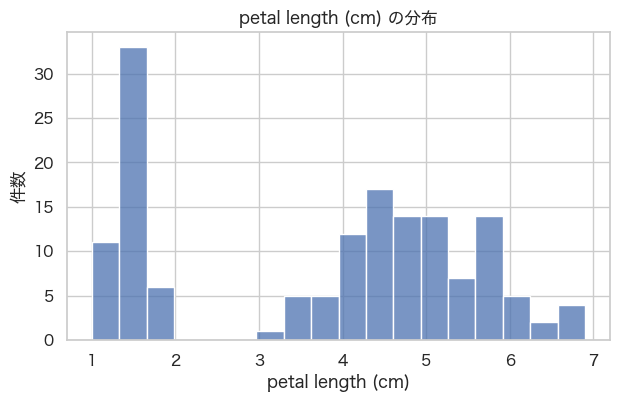

In [7]:
# ===== Step 2: シンプルなヒストグラム =====
# 前のセルで指定した列と区間境界をそのまま使います。
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x=feature, bins=bin_edges)
plt.title(f'{feature} の分布')
plt.xlabel(feature)
plt.ylabel('件数')
plt.show()

# TODO: 度数分布表の件数と、対応する棒の高さを確認する

**図の読み方:** 横軸は測定値、縦軸は件数です。山の位置と値の広がりに注目します。

#### 階級を細かくしすぎるとどうなるか

同じ花びらの長さのデータを、**18階級**と**180階級**で並べてみます。データと横軸・縦軸の範囲をそろえ、階級の取り方だけを変えます。

`bins` に指定する整数は**階級数**です。同じ値の範囲では、階級数を10倍にすると階級幅（ビンサイズ）は10分の1になります。18階級が常に最適という意味ではありませんが、180階級との比較で、細かくしすぎた場合の見え方を確認できます。


In [ ]:
# ===== Step 2: 階級が細かすぎる例 =====
# 比較専用の変数を使い、Step 2・3のfeatureとbin_edgesはそのまま使えるようにします。
comparison_feature = 'petal length (cm)'
comparison_values = df[comparison_feature]
comparison_range = (comparison_values.min(), comparison_values.max())
comparison_bins = [18, 180]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, bins_count in zip(axes, comparison_bins):
    comparison_counts, comparison_edges = np.histogram(
        comparison_values, bins=bins_count, range=comparison_range
    )
    bin_width = comparison_edges[1] - comparison_edges[0]
    ax.hist(comparison_values, bins=comparison_edges, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{bins_count}階級（階級幅 約{bin_width:.3f} cm）')
    ax.set_xlabel(comparison_feature)
    ax.set_xlim(comparison_range)
    print(f'{bins_count}階級: 度数0の階級 = {(comparison_counts == 0).sum()}個')

axes[0].set_ylabel('件数')
fig.suptitle('同じデータでも、階級の取り方で見え方が変わる')
plt.tight_layout()
plt.show()

# TODO: 右の図で棒の間に隙間が多くなる理由を考える
# TODO: comparison_binsを[10, 30]などに変え、分布の傾向が読みやすいか比べる


**図の読み方:** 180階級では、細い棒と度数0の階級が多くなり、分布が細かく分断されて見えます。Irisの測定値は小数第1位まで記録されているため、0.1 cmより狭い階級に分けると、記録された値の間に空の階級が生じます。この隙間を、実際の花の長さにその値が存在しない証拠とは考えられません。

細かい棒の凹凸を多くの山と解釈すると、分布の特徴を読み違えるおそれがあります。大まかな分布を知りたい場合、階級を細かくしすぎるのは不適切です。データの件数・記録の細かさ・見る目的に合わせて階級幅を選び、複数の設定で傾向を確かめましょう。

左右の図はどちらも縦軸が件数なので、階級幅が変われば棒の高さも変わります。個々の棒の高さが同じになるかではなく、値の集まる範囲と分布の読み取りやすさを比較してください。


---

### Step 3: 全体の分布を花の種類で色分けする

全体のヒストグラムに見える山は、どの種類の花に対応するのでしょうか。
Step 2と同じ測定項目・同じ階級で色分けし、`species` と測定値の関係を確認します。
`hue='species'` は、最初に準備した種類名の列で色を分ける指定です。

この図は積み上げではなく、種類ごとの件数を重ねて表示します。色が重なる区間では、複数の種類の値が同じ階級に入っています。


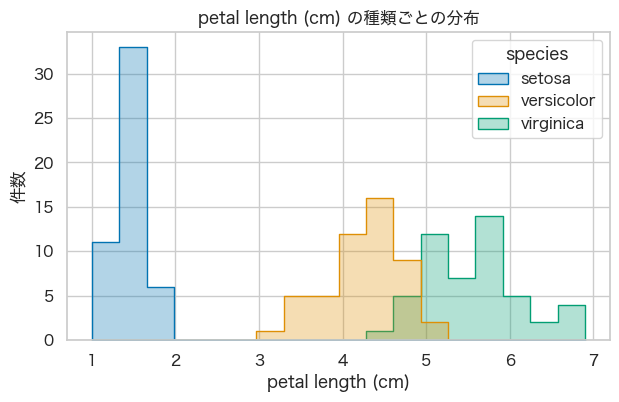

In [8]:
# ===== Step 3: 種類ごとのヒストグラム =====
# Step 2のfeatureとbin_edgesを使って、全体の図と比べる
plt.figure(figsize=(7, 4))
sns.histplot(
    data=df, x=feature, hue='species',
    bins=bin_edges, element='step', common_bins=True,
    hue_order=species_order, palette=species_palette,
    stat='count', multiple='layer', alpha=0.3
)
plt.title(f'{feature} の種類ごとの分布')
plt.xlabel(feature)
plt.ylabel('件数')
plt.show()

# TODO: Step 2でfeatureを変え、表・全体の図・種類別の図を順に実行する

**図の読み方:** 色ごとの分布の位置と、種類どうしが重なる範囲に注目します。

---

### Step 4: 棒グラフで種類ごとの平均を比較

Step 1では全ての花をまとめた平均を確認しました。ここでは `groupby('species')` で種類ごとに分け、4つの特徴量の平均を比べます。

平均のようなカテゴリ間の大小比較は、棒の高さを見比べられる棒グラフが適しています。各特徴量の中で種類ごとの平均を比較してください。4つの特徴量は同じcm単位ですが、花びらとがく片、長さと幅では測定対象が異なります。この図では同じ特徴量の中で種類間の差に注目します。平均ではばらつきが見えないため、あとで箱ひげ図も使います。

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


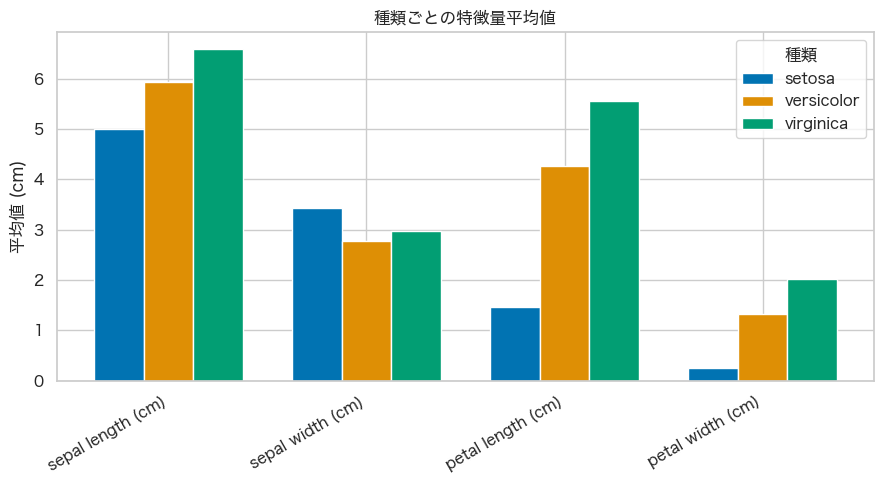

In [9]:
# ===== Step 4: 棒グラフ =====
# 各種類の「特徴量の平均値」を、特徴量ごとに並べた棒グラフで比べます。
# 同じ特徴量の中で、種類ごとの棒の高さを比較します。
# TODO: どの特徴量で種類間の平均差が大きいかを確認する

# groupby('species') で種類ごとにグループ分けし、数値列の平均を計算します。
# 結果として「種類 × 特徴量」の表ができます。
mean_by_species = df.groupby('species')[numeric_columns].mean().reindex(species_order)

display(mean_by_species)  # 集計した表と図の値を照らし合わせる

x = np.arange(len(mean_by_species.columns))  # 特徴量ごとの位置
bar_width = 0.25  # 3種類の棒を横に並べる幅

plt.figure(figsize=(9, 5))

# 種類ごとに、特徴量の位置を少しずつずらして棒を並べます。
for i, species in enumerate(mean_by_species.index):
    offset = (i - (len(mean_by_species.index) - 1) / 2) * bar_width
    plt.bar(
        x + offset,
        mean_by_species.loc[species],
        width=bar_width,
        label=species,
        color=species_palette[species]
    )

plt.title('種類ごとの特徴量平均値')
plt.xticks(x, mean_by_species.columns, rotation=30, ha='right')
plt.legend(title='種類')
plt.ylabel('平均値 (cm)')
plt.tight_layout()
plt.show()

**図の読み方:** 各特徴量の中で、種類ごとの棒の高さを比べます。横軸は特徴量の名前で、時間の順序を表していません。棒を線で結んでも時間に沿った変化にはなりません。平均の差だけでは個々の花の値の重なりは分からないため、分布の図も合わせて読みます。

---

### Step 5: 件数を割合として見る

Step 1の `value_counts()` で確認した種類ごとの件数を、今度は円グラフで表示します。同じ集計でも、表は正確な件数、円グラフは全体に占める割合を確認しやすい形です。

#### 解説: 円グラフとは

円グラフは、カテゴリごとの割合を視覚的に把握するのに適しています。
全体に対する各クラスの大きさがひと目でわかります。

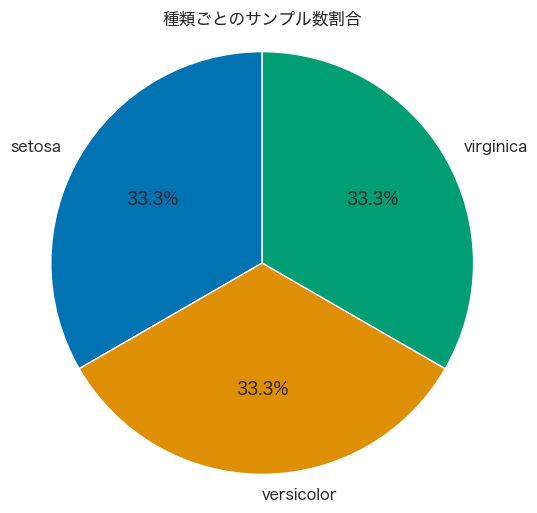

In [11]:
# ===== Step 5: 円グラフ =====
# TODO: 各種類の割合がどうなっているか確認する
species_count = df['species'].value_counts().reindex(species_order)

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    species_count.values,
    labels=species_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[species_palette[species] for species in species_count.index]
)
plt.title('種類ごとのサンプル数割合')
plt.axis('equal')
plt.show()

**図の読み方:** 各種類の割合を、Step 1で確認した件数と照らし合わせます。

ここで分かるのは、このデータセット内の構成比です。各種類が50件ずつ収録されていることから、自然界でも同じ割合で存在すると結論づけることはできません。


---

### Step 6: 平均の違いを、ばらつきも含めて確かめる

平均が離れていても、個々の花の値が重なることはあります。種類別のヒストグラムに続き、箱ひげ図で中央値とばらつきを比較しましょう。

箱の下端は25%の位置（第1四分位数）、中央線は50%の位置（中央値）、上端は75%の位置（第3四分位数）です。箱は中央50%のデータの範囲を表します。
ひげの外の点は、一定の基準で選ばれた外れ値候補です。入力ミスと決まったわけではありません。

この図では `IQR = Q3 - Q1` とし、ひげは `Q1 - 1.5 × IQR` 以上、`Q3 + 1.5 × IQR` 以下にある観測値の最小・最大まで伸びます。ひげの端は、その計算上の境界そのものではありません。範囲外の値を点で表示します。


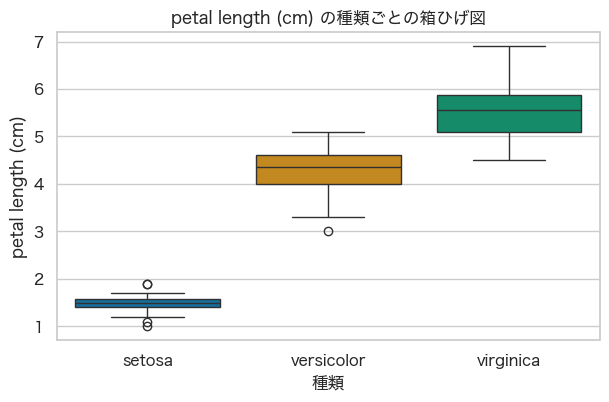

In [12]:
# ===== Step 6: 箱ひげ図 =====
# 箱ひげ図は、データの「ばらつき方」や「外れ値（極端に外れた値）」を視覚的に確認するのに適しています。
# 箱の中央の線が「中央値（データを順に並べたとき真ん中にくる値）」、
# 箱の下端は第1四分位数（25%）、上端は第3四分位数（75%）です。
# TODO: target_feature を別の列に変えて、分かれやすい特徴量を探す
target_feature = 'petal length (cm)'  # 縦軸に表示したい列を指定します

plt.figure(figsize=(7, 4))

# sns.boxplot が箱ひげ図を描く関数です。
# x='species' で横軸に種類を、y=target_feature で縦軸に見たい特徴量を指定します。
# 種類ごとに箱が分かれて表示されるので、値の分布の違いが比較しやすくなります。
sns.boxplot(
    data=df, x='species', y=target_feature, hue='species',
    order=species_order, hue_order=species_order, palette=species_palette,
    dodge=False, whis=1.5
)
# 横軸に種類名があるため、重複する凡例を省く
legend = plt.gca().get_legend()
if legend is not None:
    legend.remove()

plt.title(f'{target_feature} の種類ごとの箱ひげ図')
plt.xlabel('種類')
plt.ylabel(target_feature)
plt.show()

**図の読み方:** 中央値の位置、箱の高さ、種類どうしの重なりに注目します。

---

### Step 7: 2つの測定項目を組み合わせる

ここまでは測定項目ごとの分布や集計を見ました。Irisの分析の最後に、花びらの長さと幅を同時に見てみます。
散布図の**1点は表の1行、つまり1つの花**です。点の横位置が長さ、縦位置が幅、色が種類を表します。
1つの項目だけを見る場合に比べ、種類の分かれ方はどう変わるでしょうか。

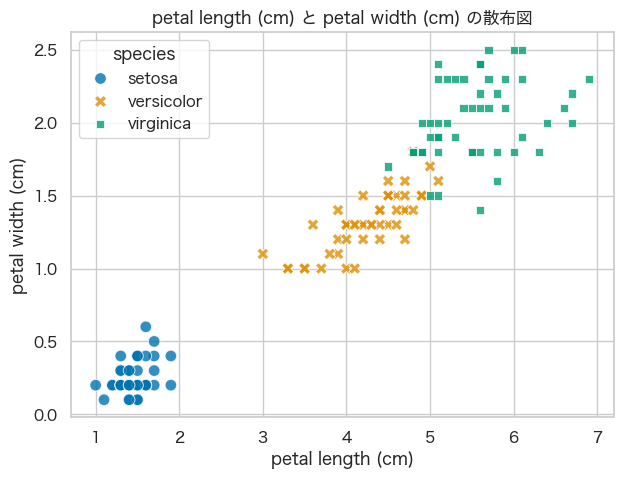

In [13]:
# ===== Step 7: 散布図 =====
# 散布図は、2つの特徴量の「関係性」を点の集まりで表したものです。
# 2つの列を横軸・縦軸に割り当て、各サンプルを1つの点としてプロットします。
# 点が右上に集まっていれば「両方が大きい」傾向、左下に集まれば「両方が小さい」傾向があることが分かります。
# TODO: x_feature と y_feature を変えて、種類が分かれやすい組み合わせを探す
x_feature = 'petal length (cm)'  # 横軸に使う列
y_feature = 'petal width (cm)'   # 縦軸に使う列

plt.figure(figsize=(7, 5))

# sns.scatterplot が散布図を描く関数です。
# x=, y= で横軸・縦軸の列を指定します。
# hue='species' で種類ごとに色を変えます。これで「どの種類がどのあたりに集まっているか」が分かります。
# s=70 は点のサイズを指定しています（デフォルトより少し大きめにして見やすくしています）。
sns.scatterplot(
    data=df, x=x_feature, y=y_feature, hue='species', style='species',
    hue_order=species_order, style_order=species_order,
    palette=species_palette, s=70, alpha=0.8
)

plt.title(f'{x_feature} と {y_feature} の散布図')
plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.show()

**図の読み方:** 点の集まりの向きと、色ごとの集まりの重なりに注目します。

同じ座標の花があると点が重なるので、見える点の数が件数と一致するとは限りません。また、全体の右上がりの傾向が、各種類の内部でも同じ強さとは限りません。色ごとの傾向も確認し、関係の強さと分類のしやすさを分けて考えます。


---

### Step 8: 折れ線グラフで月平均気温の変化を見る

ここまでのIrisでは、分布・種類ごとの差・特徴量どうしの関係を調べました。次は時間に沿った変化を見るため、気象データに切り替えます。

折れ線グラフは、時間など順序のある軸に沿った変化を見るために使います。ここでは、気象庁の観測データから作成したCSVを読み込み、広島・津山・金沢の2025年1〜12月の月平均気温を描きます。

- 1行は1か月、`月` 列は1〜12月を表します。
- `広島`・`津山`・`金沢` 列は各地点の月平均気温（℃）です。
- 点は各月の平均値、線は隣り合う月の点を結び、変化を見やすくします。

**CSVの準備:** Notebookと同じフォルダに `data` フォルダを置き、その中に `monthly_mean_temperature_2025.csv` を入れてください。リポジトリのルートから実行する場合にも対応しています。Colabでは、左側のファイル欄で `data` フォルダを作成し、CSVをアップロードしてください。

出典とデータの説明は [data/README.md](data/README.md) に記載しています。


,月,広島,津山,金沢
0,1,5.7,2.8,4.7
1,2,4.1,1.5,3.4
2,3,10.6,7.8,8.8
3,4,15.5,13.3,13.4
4,5,19.6,17.6,18.2
5,6,24.7,23.6,23.7
6,7,29.8,28.4,29.4
7,8,29.7,27.7,29.0
8,9,27.0,24.5,26.1
9,10,21.0,18.2,18.8


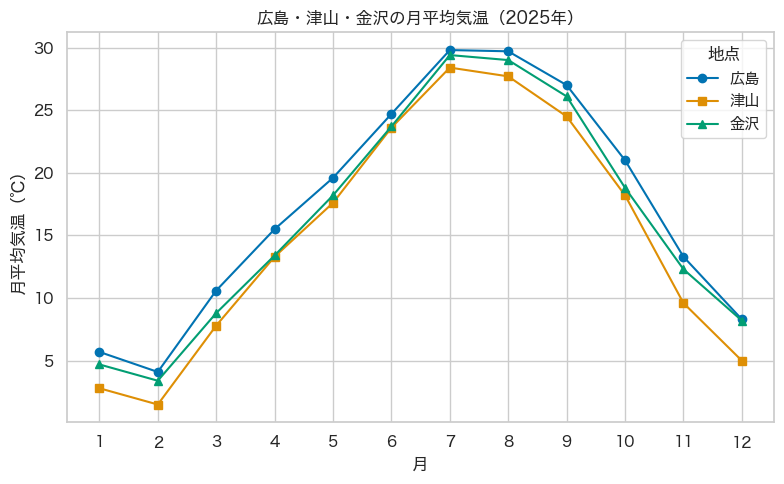

In [10]:
# ===== Step 8: 気象データの折れ線グラフ =====
from pathlib import Path

# CSVを読み込む（Notebookのフォルダ、またはリポジトリのルートから実行）
weather_csv = Path('data/monthly_mean_temperature_2025.csv')
if not weather_csv.exists():
    weather_csv = Path('notebook/data/monthly_mean_temperature_2025.csv')
if not weather_csv.exists():
    raise FileNotFoundError(
        '気象CSVが見つかりません。dataフォルダに '
        'monthly_mean_temperature_2025.csvを置いてください。'
    )
weather_df = pd.read_csv(weather_csv, encoding='utf-8-sig').sort_values('月')
display(weather_df)

# 3地点の月平均気温を、同じ横軸・縦軸に描く
cities = ['広島', '津山', '金沢']
weather_colors = sns.color_palette('colorblind', 3)
weather_markers = ['o', 's', '^']
plt.figure(figsize=(8, 5))
for city, color, marker in zip(cities, weather_colors, weather_markers):
    plt.plot(
        weather_df['月'], weather_df[city],
        label=city, color=color, marker=marker
    )

plt.title('広島・津山・金沢の月平均気温（2025年）')
plt.xlabel('月')
plt.ylabel('月平均気温（℃）')
plt.xticks(range(1, 13))  # 横軸に1〜12月を表示する
plt.legend(title='地点')
plt.tight_layout()
plt.show()

# TODO: 各地点で気温が最も高い月・低い月を、表と図で確認する
# TODO: 地点間の気温差が大きい月と小さい月を探す


**図の読み方:** 各線の上昇・下降から月ごとの変化を読み、同じ月の点の高さから地点間の違いを比べます。

線で結んだ月の間の値は、直接観測した値ではありません。月平均では日ごとの変動は分かりません。また、2025年の1年分の観測値なので、複数年の平均的な気候や長期的な温暖化の傾向は、この図だけでは判断できません。


---

## まとめとレポート

この回の提出物は **レポート1本** です。演習A〜Cの結果と説明をまとめ、lesson01と同様にWord形式で大学の電子メール（kazuhisa_fujita@komatsu-u.ac.jp）へ提出してください。

授業中に実行したセルと図を使って作成できます。各演習で指定したコード・出力・図を選び、以下の構成にまとめます。

| 節 | 書く内容 |
| --- | --- |
| 1. 学んだことの要約 | NumPy配列、DataFrame、グラフの役割と、この回で学んだこと |
| 2. 演習の結果と説明 | 演習A〜Cで指定したコード・結果・図と説明 |
| 3. 分からなかった点 | 詰まった場所や、理解が十分でない点 |

途中の読み方のポイントは、結果を説明するための手がかりです。提出する内容は、次の演習A〜Cにまとめます。

### 演習A: 配列とデータの確認

準備とStep 0・1で実行した結果を使い、レポートの節2に次をまとめてください。

1. `scores.shape`、`scores.mean(axis=1)`、`scores.mean(axis=0)` のコードと出力を載せ、行数・列数と2種類の平均の違いを説明する。
2. Irisの1行と4つの特徴量が何を表すかを説明し、表の行数・列数と、種類ごとの件数を載せる。
3. 4つの特徴量の基本統計量から1列を選び、列名・平均・最小値・最大値を記す。

配列の準備では、行と列に数値を並べて計算しました。Irisでは、同じように行と列を持つ表を使い、列名を確認しながら集計しています。


### 演習B: ヒストグラムで分布を見る

Step 2・3で、4つの特徴量から1つを選び、次をレポートの節2にまとめてください。

1. 選んだ列名と階級数 `n_bins` を記す。
2. 度数分布表を作るコードと表、種類別ヒストグラムを描くコードと図を載せる。
3. データが多い範囲と、種類どうしの分布が重なる範囲を説明する。

列名や階級数を変えた場合は、Step 2の度数分布表→全体のヒストグラム→Step 3の種類別ヒストグラムの順に実行してください。表と図は同じ `feature` と `bin_edges` を使います。

### 演習C: 箱ひげ図と散布図で種類の違いを考える

Step 6・7で列名を選び、次をレポートの節2にまとめてください。

1. 1つの特徴量の箱ひげ図について、コードと図を載せ、種類ごとの中央値とばらつきの違いを説明する。
2. 2つの特徴量の散布図について、コードと図を載せ、種類ごとの点の集まりと重なりを説明する。
3. 2つの図を根拠に、「花の種類によって、長さや幅はどう違うか」を**事実・解釈・限界**に分けてまとめる。

- **事実:** 図に見える分布・中央値・重なりなど
- **解釈:** その違いから考えられること
- **限界:** 図だけでは言えないことや、今回見ていないこと

演習Bと同じ特徴量を使っても構いません。演習Bのヒストグラム、演習Cの箱ひげ図と散布図の計3図を、レポートの基本の図とします。

### 任意の追加分析

さらに調べたい場合は、階級数を変えた比較、Step 8の気温の折れ線グラフ、発展の図、ワインデータの可視化のいずれかを選び、同じレポートの節2の末尾に追加できます。追加した図と、そこから分かったことを簡潔に記してください。

### レポート本文（テンプレート）

以下をWordにコピーし、各欄を埋めてください。コード・出力・図は、対応する演習の欄に貼り付けます。

---

# テーマ2 データ可視化とEDA レポート

氏名:
提出日:

## 1. 学んだことの要約

## 2. 演習の結果と説明

### 演習A（配列とデータの確認）
- scoresのコード・出力と、shape・行平均・列平均の説明:
- Irisの1行と特徴量の意味:
- 表の行数・列数、種類名と件数:
- 選んだ特徴量の平均・最小値・最大値:

### 演習B（ヒストグラムで分布を見る）
- 選んだ列名と階級数:
- コード・度数分布表・種類別ヒストグラム:
- 分布と重なりの説明:

### 演習C（箱ひげ図と散布図で種類の違いを考える）
- 選んだ列名:
- コード・箱ひげ図・散布図:
- 中央値・ばらつき・点の集まりの説明:
- 事実:
- 解釈:
- 限界:

### 任意の追加分析（取り組んだ場合）

## 3. 分からなかった点

### 提出前チェック

- 演習A〜Cがそろい、コードだけでなく出力と説明もある。
- 演習Bの表と図で、特徴量・階級数・区間境界が一致している。
- 基本の3図（種類別ヒストグラム・箱ひげ図・散布図）に、読める軸ラベル・単位・種類の区別がある。
- 図や数値を根拠に説明し、事実・解釈・限界を分けている。
- 氏名・提出日を記入し、未記入のテンプレート欄を残していない。


### 参考資料

- [scikit-learn: Irisデータの読み込み](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)
- [seaborn: 箱ひげ図とひげの定義](https://seaborn.pydata.org/generated/seaborn.boxplot.html)


---

## 付録: 発展の可視化（任意）

ここからは、基本学習とレポートの案内を終えた後に試す参考例です。Step 0〜7の変数を使うため、先にIrisのセルを実行してください。興味のある項目を試し、レポートに使う場合は最後の「任意の追加分析」にまとめます。

### 相関ヒートマップで特徴量どうしの関係を見る

相関係数は、2つの数値列がどの程度一緒に増減するかを -1 から +1 で表します。+1 に近いほど同じ向き、-1 に近いほど反対向きに変化し、0 に近いほど直線的な関係が弱いことを示します。相関があっても、因果関係があるとは限りません。

ヒートマップでは、相関係数を色と数値で一覧できます。

全種類をまとめた相関には、種類間の平均の違いも影響します。散布図を色ごとに読み、全体の相関をそのまま種類内の関係とみなさないようにします。


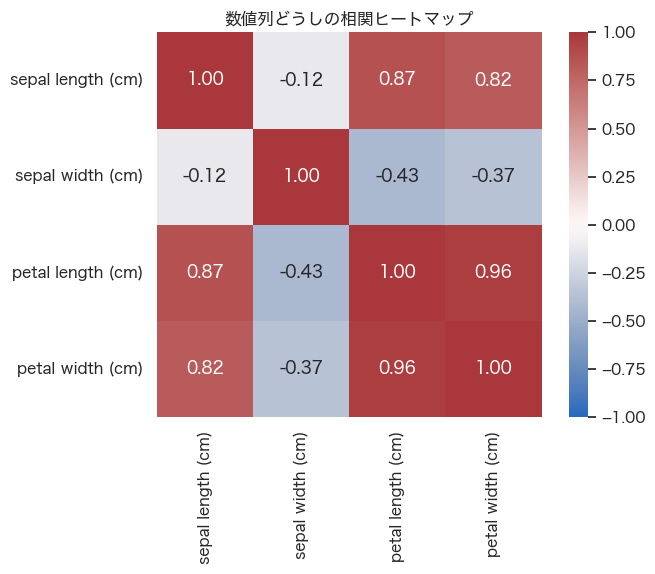

In [14]:
# ===== 相関ヒートマップ =====
corr_matrix = df[numeric_columns].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', vmin=-1, vmax=1, center=0, fmt='.2f', square=True)
plt.title('数値列どうしの相関ヒートマップ')
plt.show()

### pairplot で全体像を確認

pairplot は、各数値特徴量の分布と、特徴量どうしの組み合わせを一度に表示します。種類ごとに色分けし、どの組み合わせで集まりが分かれて見えるかを観察します。

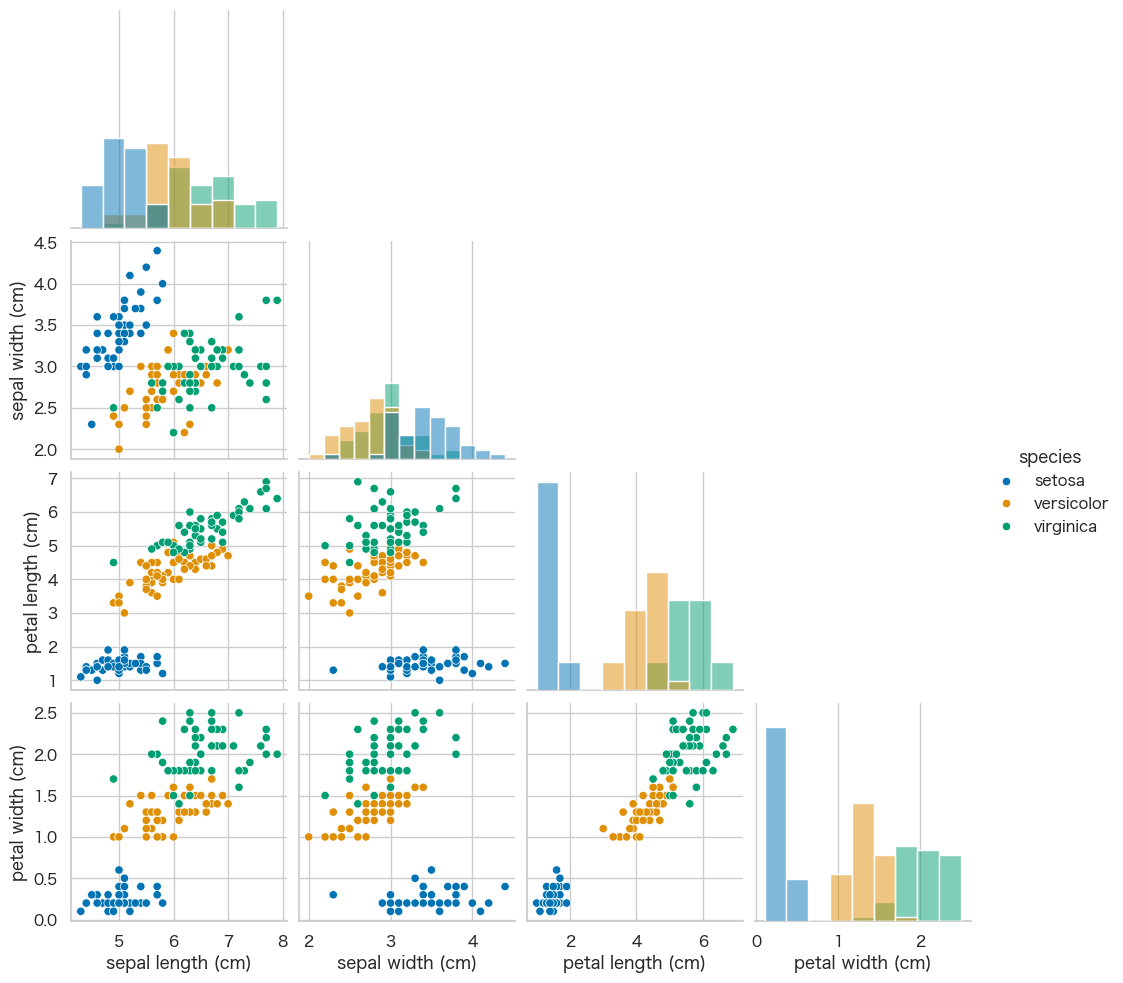

In [15]:
# ===== pairplot =====
# pairplot は、すべての数値列の「2列の組み合わせ」について散布図を一気に描いてくれる便利な機能です。
# 対角線上にはヒストグラムが描かれ、それ以外のマスには各ペアの散布図が描かれます。
# これを1枚描くだけで、どの列の組み合わせが種類を分けやすいかが比較しやすくなります。

# 描画に使う列として、数値列（4つ）に種類名を追加します。
# hue='species' で色分けするために、種類名の列も含める必要があります。
pairplot_columns = iris.feature_names + ['species']

# sns.pairplot がこの図を描く関数です。
# hue='species' で種類ごとに色を変えます。
# corner=True は、左下の半分だけを描く設定です（右上は左下の鏡像なので省略してすっきりさせます）。
g = sns.pairplot(df[pairplot_columns], hue='species', hue_order=species_order, palette=species_palette,
                 corner=True, diag_kind='hist')

plt.show()

### IQR で外れ値の候補を探す

箱ひげ図で外れ値を目で確認できましたが、ここでは数値でも見てみます。

**IQR の考え方:**
- `IQR = Q3 - Q1` （第3四分位数 - 第1四分位数）
- 下限: `Q1 - 1.5 × IQR`
- 上限: `Q3 + 1.5 × IQR`
- この範囲外にある値を「外れ値候補」とします

ここでは全種類をまとめて計算します。箱ひげ図は種類ごとに集計するため、候補の判定が一致しない場合があります。候補があっても、入力ミスとは限りません。

In [16]:
# ===== IQR で外れ値候補を確認 =====
# IQR（四分位範囲：Inter-Quartile Range）は、データの中央50%がどれくらいの幅に広がっているかを示す値です。
# この基準で範囲外の値を探します。異常や入力ミスと確定する判定ではありません。
# TODO: feature_to_check を変えて、外れ値候補の件数を確認する
feature_to_check = 'sepal width (cm)'  # 外れ値を確認したい列を指定します

# quantile(0.25) は「下から25%の位置の値（第1四分位数：Q1）」を取得します。
# つまり、データを小さい順に並べたとき、下から4分の1のところにある値です。
q1   = df[feature_to_check].quantile(0.25)

# quantile(0.75) は「下から75%の位置の値（第3四分位数：Q3）」を取得します。
q3   = df[feature_to_check].quantile(0.75)

# IQR は Q3 と Q1 の差です。データの中央50%の広がりを表します。
iqr  = q3 - q1

# 外れ値の基準となる下限と上限を計算します。
# 一般的なルールでは「Q1 - 1.5×IQR より小さい」または「Q3 + 1.5×IQR より大きい」値を外れ値候補とします。
low  = q1 - 1.5 * iqr  # 下限：これより小さい値は外れ値の候補
high = q3 + 1.5 * iqr  # 上限：これより大きい値は外れ値の候補

# 外れ値候補だけを取り出します。
# 条件を ( ) で囲み、|（縦棒）でつなぐことで「下限より小さい または 上限より大きい」という
# 2つの条件のどちらかを満たす行だけを抽出しています。
outliers = df[
    (df[feature_to_check] < low) | (df[feature_to_check] > high)
]

# 結果をわかりやすく表示します。
print('確認する列 =', feature_to_check)
print('下限 =', round(low, 2))   # round(..., 2) で小数点以下2桁に丸めて見やすくします
print('上限 =', round(high, 2))
print('外れ値候補の件数 =', len(outliers))  # len() で外れ値の行数を数えます

# 外れ値候補のデータの中身を表示します（先頭5行だけ）。
# 特徴量の値と種類名だけを表示して、どの種類に外れ値が多いかを確認できます。
display(outliers[[feature_to_check, 'species']].head())

確認する列 = sepal width (cm)
下限 = 2.05
上限 = 4.05
外れ値候補の件数 = 4


,sepal width (cm),species
15,4.4,setosa
32,4.1,setosa
33,4.2,setosa
60,2.0,versicolor


### レーダーチャートで種類を比較する

各軸は特徴量を表し、種類ごとの平均値を輪郭として描きます。特徴量ごとに全データの最小値を0、最大値を1にそろえているため、ここでは絶対値ではなく種類間の相対的な違いを見ます。

軸の並べ方でも輪郭が変わるため、塗られた面積を総合的な大きさや性能として比較しません。正規化に使う最小値と最大値は、このデータセット内の値です。


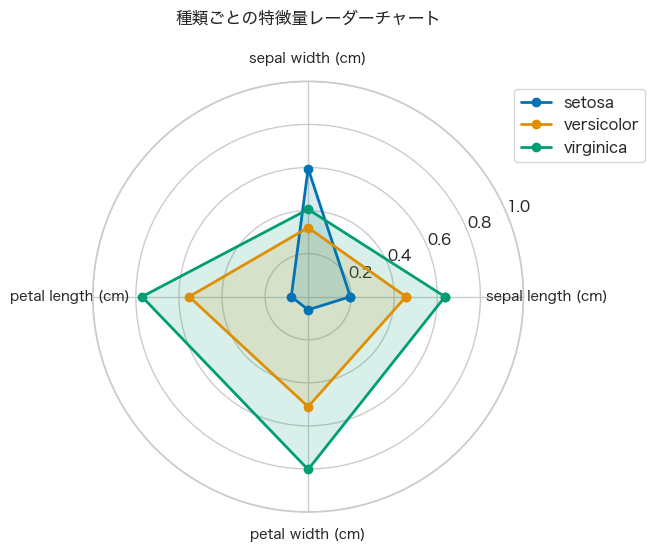

In [17]:
# ===== レーダーチャート =====
# レーダーチャートは、複数の特徴量を1つの図で比較できます。ただし、単位や値の範囲が異なる特徴量をそのまま重ねると誤解を招くため、ここでは特徴量ごとに0〜1へ正規化します。
# 各特徴量が1方向の軸になり、値が大きいほど外側に広がります。
# 種類ごとに「形」が違うので、各特徴量の相対的な大小を比較できます。大きい値が優れているという意味ではありません。
# TODO: 正規化した各特徴量の平均に注目し、種類間の違いを確認する

# 種類ごとの各特徴量の平均値を計算し、特徴量ごとに0〜1へ正規化します。
mean_by_species = df.groupby('species')[numeric_columns].mean().reindex(species_order)
feature_min = df[iris.feature_names].min()
feature_max = df[iris.feature_names].max()
normalized_mean_by_species = (mean_by_species - feature_min) / (feature_max - feature_min)

# 特徴量の名前のリストを取得します（これがレーダーチャートの各軸のラベルになります）。
features = iris.feature_names

# 軸の数（＝特徴量の数）を取得します。アヤメなら4つです。
num_vars = len(features)

# np.linspace(0, 2π, num_vars) は、0 から 2π（360度）の間を num_vars 個に等分した角度を作ります。
# endpoint=False は、最後の点（2π）を含めない設定です（最初の点0と同じ角度になるのを防ぐため）。
# .tolist() で numpy 配列を普通のリストに変換します。
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# レーダーチャートを「閉じた形」にするため、最初の角度をリストの最後にもう一度追加します。
# これがないと、最後の軸から最初の軸に線が引かれず、図が開いたままになってしまいます。
angles += angles[:1]  # 閉じるために最初の角度を最後に追加

plt.figure(figsize=(7, 7))

# subplot(111, projection='polar') は、極座標（円形の座標系）でグラフを描くための領域を作ります。
# 111 は「1行1列の1番目」という意味で、1つの図だけを描く場合の定番の指定です。
ax = plt.subplot(111, projection='polar')

# 種類ごとに1本ずつ線を引きます。
for species in normalized_mean_by_species.index:
    # その種類の平均値を行から取り出し、リストに変換します。
    values = normalized_mean_by_species.loc[species].values.flatten().tolist()

    # 図を閉じるため、最初の値をリストの最後にもう一度追加します（角度と同じ理由です）。
    values += values[:1]  # 閉じるために最初の値を最後に追加

    # ax.plot で線を、ax.fill で内側を薄く塗りつぶします。
    # linewidth=2 は線の太さ、marker='o' はデータ点に丸印、alpha=0.15 は塗りつぶしの透明度です。
    ax.plot(angles, values, linewidth=2, label=species, marker='o', color=species_palette[species])
    ax.fill(angles, values, alpha=0.15, color=species_palette[species])

# 各軸の位置に特徴量名を表示します（angles[:-1] は最後の重複した角度を除外したリストです）。
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=10)

# 正規化した値は0〜1の範囲なので、半径も0〜1に設定します。
ax.set_ylim(0, 1)

# pad=20 はタイトルと図の間に余白を入れる設定です。
ax.set_title('種類ごとの特徴量レーダーチャート', pad=20)

# 凡例を表示します。bbox_to_anchor で凡例の位置を少し外側にずらしています。
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()